# Setup

In [1]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
import random
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables


import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [2]:
def calc_wape(total_error_abs, total_sales):
    return round(total_error_abs / total_sales, 4) if total_sales != 0 else np.nan

def calc_bias(total_error, total_sales):
    return round(total_error / total_sales, 4) if total_sales != 0 else np.nan

def calc_mae(error_abs):
    if len(error_abs) == 0:
        return np.nan
    return round(np.mean(error_abs), 4)

def calc_rmse(error):
    if len(error) == 0:
        return np.nan
    return round(np.sqrt(np.mean(np.square(error))), 4)

In [3]:
def eval_forecast(df, forecast_dict):
    """
    Calcula WAPE, BIAS, MAE y RMSE para cada forecast usando
    las funciones definidas y validando con distintas columnas de ventas reales.
    
    Args:
        df (pd.DataFrame): dataframe con ventas reales y forecasts
        forecast_dict (dict): diccionario {forecast_col: real_col}
    
    Returns:
        pd.DataFrame con métricas por método
    """
    results = []

    for forecast_col, real_col in forecast_dict.items():
        actual = df[real_col].fillna(0).astype(float)
        forecast = df[forecast_col].fillna(0).astype(float)

        error = forecast - actual
        error_abs = np.abs(error)

        total_error_abs = error_abs.sum()
        total_error = error.sum()
        total_sales = actual.sum()

        results.append({
            "forecast": forecast_col,
            "tipo_venta_real": real_col,
            "wape": calc_wape(total_error_abs, total_sales),
            "bias": calc_bias(total_error, total_sales),
            "mae": calc_mae(error_abs),
            "rmse": calc_rmse(error)
        })
    
    return pd.DataFrame(results)

# Load data

In [4]:
data_all = pd.read_parquet('../sandbox/data_genex_venta_transfer.parquet')

In [5]:
factores_historicos = pd.read_parquet('../data/processed/factores_invierno_2024.parquet')

data_all = pd.merge(
    data_all,
    factores_historicos,
    on=['cod_ano_comercial', 'cod_semana','nombre_depto','nombre_linea'],
    how='left'
)

In [6]:
cond1 = data_all["can_final"] > 0 # Que saliera repo
cond2 = data_all["repo_x_dda"] > 0 # Que hubiera repo x dda calculada
cond3 = data_all["repo_x_dda"] >= data_all["repo_x_ume"] # Que la repo sea por demanda

data_repo_x_dda = data_all.loc[cond1 & cond2 & cond3].copy()

# Modelacion forecasts

In [7]:
data_repo_x_dda['forecast_tricot'] = (data_repo_x_dda['vta_promedio'] * data_repo_x_dda['factor'] * data_repo_x_dda['semana_vta']).fillna(0).round(0).astype('UInt16')
data_repo_x_dda['forecast_factor_hist'] = (data_repo_x_dda['vta_promedio'] * data_repo_x_dda['factor_historico'] * data_repo_x_dda['semana_vta']).fillna(0).round(0).astype('UInt16')
data_repo_x_dda['forecast_vta_promedio'] = (np.minimum(data_repo_x_dda['vta_promedio'], 1) * data_repo_x_dda['factor'] * data_repo_x_dda['semana_vta']).fillna(0).round(0).astype('UInt16')
data_repo_x_dda['forecast_sv4'] = (data_repo_x_dda['vta_promedio'] * data_repo_x_dda['factor'] * 4).fillna(0).round(0).astype('UInt16')
data_repo_x_dda['forecast_f1'] = (data_repo_x_dda['vta_promedio'] * 1 * data_repo_x_dda['semana_vta']).fillna(0).round(0).astype('UInt16')

In [8]:
random_factor = np.random.uniform(0.5, 1, size=len(data_repo_x_dda))
random_vta_promedio = np.random.uniform(0.8, 1.2, size=len(data_repo_x_dda))

data_repo_x_dda['forecast_aleatorio'] = (random_factor * random_vta_promedio * 8).round(0).astype('uint16')

In [9]:
data_repo_x_dda = data_repo_x_dda[data_repo_x_dda['date'] != dt.date(2025, 5, 5)]

# Valida

In [10]:
forecast_dict = {
    "forecast_tricot": "real_sales",
    "forecast_factor_hist": "real_sales",
    "forecast_sv4": "real_sales_n4",
    "forecast_vta_promedio": "real_sales",
    "forecast_f1": "real_sales",
    "forecast_aleatorio": "real_sales"
}

In [19]:
dict_names = {
    "forecast_tricot": "Actual",
    "forecast_factor_hist": "Factor histórico",
    "forecast_sv4": "4 semanas de venta",
    "forecast_vta_promedio": "Venta prom. límitada a 1",
    "forecast_f1": "Factor fijo en 1",
    "forecast_aleatorio": "Aleatorio con 8 semanas fijo"
}

metrics = eval_forecast(data_repo_x_dda, forecast_dict)

metrics['forecast'] = metrics['forecast'].map(dict_names)

print(metrics)

                       forecast tipo_venta_real    wape    bias      mae  \
0                        Actual      real_sales  1.1861  1.0404   7.3976   
1              Factor histórico      real_sales  1.6933  1.3731  10.5604   
2            4 semanas de venta   real_sales_n4  1.2644  1.0489   4.5780   
3      Venta prom. límitada a 1      real_sales  0.7973  0.3178   4.9728   
4              Factor fijo en 1      real_sales  0.8056  0.4102   5.0244   
5  Aleatorio con 8 semanas fijo      real_sales  0.7630 -0.0377   4.7587   

      rmse  
0  19.4727  
1  59.2384  
2  10.6231  
3   7.9256  
4  10.8490  
5   8.0034  


In [20]:
colors = ['orange' if x == 'Actual' else 'gray' for x in metrics['forecast']]

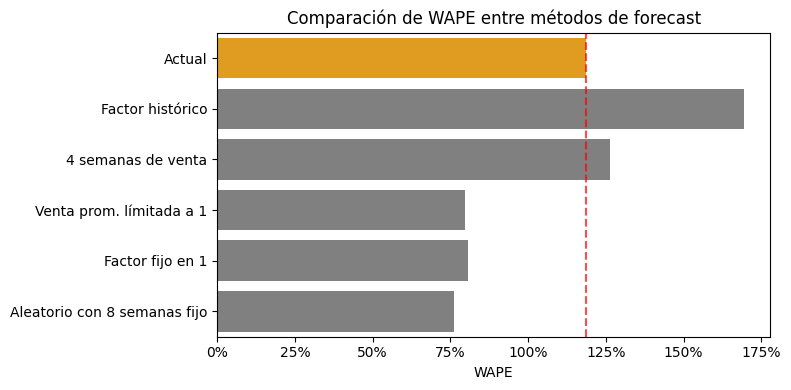

In [21]:
plt.figure(figsize=(8, 4))
sns.barplot(data=metrics, x="wape", y="forecast", hue="forecast", palette=colors, legend=False)

# Línea vertical en el valor de Actual
actual_wape = metrics[metrics['forecast'] == 'Actual']['wape'].iloc[0]
plt.axvline(x=actual_wape, color='red', linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.title('Comparación de WAPE entre métodos de forecast')
plt.xlabel('WAPE')
plt.ylabel('')

plt.tight_layout()
plt.show()

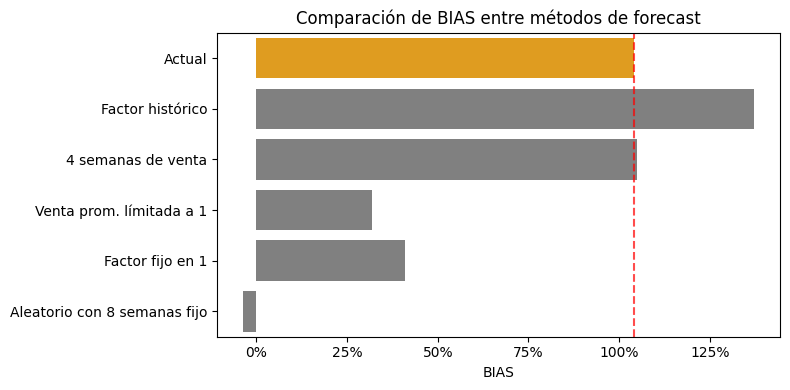

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(data=metrics, x="bias", y="forecast", hue="forecast", palette=colors, legend=False)

# Línea vertical en el valor de Actual
actual_bias = metrics[metrics['forecast'] == 'Actual']['bias'].iloc[0]
plt.axvline(x=actual_bias, color='red', linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.title('Comparación de BIAS entre métodos de forecast')
plt.xlabel('BIAS')
plt.ylabel('')

plt.tight_layout()
plt.show()

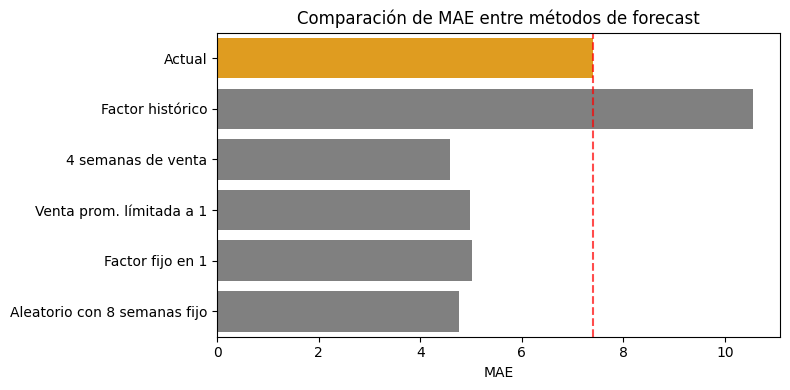

In [23]:
plt.figure(figsize=(8, 4))
sns.barplot(data=metrics, x="mae", y="forecast", hue="forecast", palette=colors, legend=False)

actual_mae = metrics[metrics['forecast'] == 'Actual']['mae'].iloc[0]
plt.axvline(x=actual_mae, color='red', linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.title('Comparación de MAE entre métodos de forecast')
plt.xlabel('MAE')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Ejemplo

In [24]:
cod_producto = 680279
cod_talla = 105

data_sample = data_repo_x_dda[data_repo_x_dda['cod_producto'] == cod_producto].copy()
data_sample = data_sample[data_sample['cod_talla'] == cod_talla].copy()

In [25]:
dict_names = {
    "forecast_tricot": "Actual",
    "forecast_factor_hist": "Factor histórico",
    "forecast_sv4": "4 semanas de venta",
    "forecast_vta_promedio": "Venta prom. límitada a 1",
    "forecast_f1": "Factor fijo en 1",
    "forecast_aleatorio": "Aleatorio"
}

In [26]:
data_sample[['nombre_sucursal','cod_producto','cod_talla','week_number','date', 'can_final','real_sales', 'real_sales_n4',
             'forecast_tricot','forecast_factor_hist', 'forecast_sv4','forecast_vta_promedio','forecast_f1','forecast_aleatorio']].sort_values('can_final', ascending=False)

,nombre_sucursal,cod_producto,cod_talla,week_number,date,can_final,real_sales,real_sales_n4,forecast_tricot,forecast_factor_hist,forecast_sv4,forecast_vta_promedio,forecast_f1,forecast_aleatorio
10334063,FLORIDA CENTER,680279,105,2,2025-03-24,40.0,13,4,45,33,22,11,32,6
20682022,MALL INDEPENDENCIA,680279,105,2,2025-03-24,40.0,9,5,45,33,22,11,32,6
11158958,MAIPU 2,680279,105,2,2025-03-24,37.0,24,6,45,33,22,11,32,7
3718057,CONCEPCION TEATRO,680279,105,2,2025-03-24,33.0,14,4,34,25,17,11,24,9
2525449,OSORNO,680279,105,2,2025-03-24,33.0,3,1,34,25,17,11,24,8
15778014,TOME L,680279,105,2,2025-03-24,33.0,10,3,34,25,17,11,24,5
25621230,MALL PZA EGANA,680279,105,2,2025-03-24,25.0,12,6,34,25,17,11,24,5
17895950,PUENTE,680279,105,2,2025-03-24,21.0,10,3,34,25,17,11,24,5
7219865,TALAGANTE,680279,105,2,2025-03-24,21.0,12,4,22,17,11,11,16,6
6701178,SAN VICENTE,680279,105,2,2025-03-24,21.0,12,2,22,17,11,11,16,9
